In [ ]:
import pandas as pd

df = pd.read_csv("combined_scaled_battery_data.csv")

print(df.shape)
print(df.columns)
print(df.head())
print(df.describe())

(15064, 9)
Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL'],
      dtype='object')
   Cycle_Index  Discharge Time (s)  Decrement 3.6-3.4V (s)  \
0          1.0             2595.30             1151.488500   
1          2.0             7408.64             1172.512500   
2          3.0             7393.76             1112.992000   
3          4.0             7385.50             1080.320667   
4          6.0            65022.75            29813.487000   

   Max. Voltage Dischar. (V)  Min. Voltage Charg. (V)  Time at 4.15V (s)  \
0                      3.670                    3.211           5460.001   
1                      4.246                    3.220           5508.992   
2                      4.249                    3.224           5508.993   
3                      4.250                    3.225           

In [2]:
!pip install xgboost
!pip install scikit-learn

## XGBoost

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("combined_scaled_battery_data.csv")
print(df.shape)
print(df.columns)
df.head()

(17658, 10)
Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL', 'Is_NASA'],
      dtype='object')


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL,Is_NASA
0,1.0,0.909368,2.248505,-2.808054,-3.115605,2.005705,1.867079,2.297202,1112,0
1,2.0,5.241828,2.317965,4.102902,-3.039831,2.045062,1.871526,2.039997,1111,0
2,3.0,5.228434,2.121319,4.138897,-3.006154,2.045063,1.871526,1.965868,1110,0
3,4.0,5.220999,2.013378,4.150895,-2.997735,2.039458,1.871526,1.875424,1109,0
4,6.0,57.099956,96.943238,4.630822,-1.541204,2.022568,31.339883,44.865103,1107,0


In [5]:
print(df.isnull().sum())
df.describe()

Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
Is_NASA                      0
dtype: int64


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL,Is_NASA
count,17658.000000,1.765800e+04,1.765800e+04,1.765800e+04,1.765800e+04,1.765800e+04,1.765800e+04,1.765800e+04,17658.000000,17658.000000
mean,478.737569,-2.430444e-16,4.989653e-17,1.889630e-15,1.496896e-15,2.575305e-17,3.154749e-16,1.440561e-16,475.453789,0.157662
std,346.867666,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,346.385696,0.364434
min,1.000000,-2.258279e+00,-1.452854e+00,-1.096750e+01,-6.850047e+00,-5.006792e+00,-2.414435e+00,-8.440053e+00,0.000000,0.000000
25%,140.250000,-3.829108e-01,-5.272823e-01,-5.883896e-01,-6.824397e-01,-8.742094e-01,-8.142953e-01,-3.903089e-01,137.000000,0.000000
50%,459.000000,-5.522698e-02,-1.115324e-01,8.779746e-02,-5.941479e-02,-1.975522e-02,7.892507e-03,7.686724e-02,448.000000,0.000000
75%,781.000000,2.764330e-01,4.595126e-01,6.594220e-01,6.898990e-01,8.459338e-01,7.615473e-01,3.665964e-01,787.000000,0.000000
max,1133.000000,5.709996e+01,9.694324e+01,4.630822e+00,6.052965e+00,3.103577e+00,3.135277e+01,4.494872e+01,1133.000000,1.000000


In [6]:
df_clean = df.copy()

time_like_cols = [
    "Discharge Time (s)",
    "Decrement 3.6-3.4V (s)",
    "Time at 4.15V (s)",
    "Time constant current (s)",
    "Charging time (s)"
]

for col in time_like_cols:
    df_clean = df_clean[df_clean[col] > 0]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (17658, 10)
Cleaned shape: (5824, 10)


In [7]:
df_clean.describe()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL,Is_NASA
count,5824.000000,5824.000000,5824.000000,5824.000000,5824.000000,5824.000000,5824.000000,5824.000000,5824.000000,5824.0
mean,226.851133,0.406103,0.607803,0.899872,-0.840510,1.051121,0.905505,0.541876,883.975962,0.0
std,134.359465,1.364517,1.330303,0.513731,0.759190,0.441939,0.784666,1.060243,133.583066,0.0
min,1.000000,0.005709,0.000278,-3.048018,-3.157701,0.002436,0.030743,0.000203,285.000000,0.0
25%,115.000000,0.227781,0.274497,0.635426,-1.280207,0.724176,0.624500,0.289879,785.000000,0.0
50%,220.000000,0.342457,0.538805,0.899386,-0.913969,1.053200,0.898556,0.488917,890.000000,0.0
75%,326.000000,0.463551,0.847508,1.127351,-0.581409,1.414719,1.192082,0.704065,995.000000,0.0
max,823.000000,57.099956,96.943238,4.630822,2.222204,3.103577,31.352774,44.948724,1133.000000,0.0


In [8]:
feature_cols = [
    "Discharge Time (s)",
    "Decrement 3.6-3.4V (s)",
    "Max. Voltage Dischar. (V)",
    "Min. Voltage Charg. (V)",
    "Time at 4.15V (s)",
    "Time constant current (s)",
    "Charging time (s)"
]

target_col = "RUL"

X = df_clean[feature_cols]
y = df_clean[target_col]

print(X.shape, y.shape)

(5824, 7) (5824,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (4659, 7) (4659,)
Test shape: (1165, 7) (1165,)


In [10]:
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

In [11]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train_imp, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
y_pred = xgb_model.predict(X_test_imp)

print("First 10 predictions:", y_pred[:10])
print("First 10 true values:", y_test.values[:10])

First 10 predictions: [1042.8976  800.7251  756.7606  766.1037  693.7795  856.1575  972.4867
  813.2021 1004.0565 1034.241 ]
First 10 true values: [1039  772  754  769  694  856  973  814 1001 1033]


In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

MAE:  7.4499
RMSE: 12.7233
R^2:  0.9908


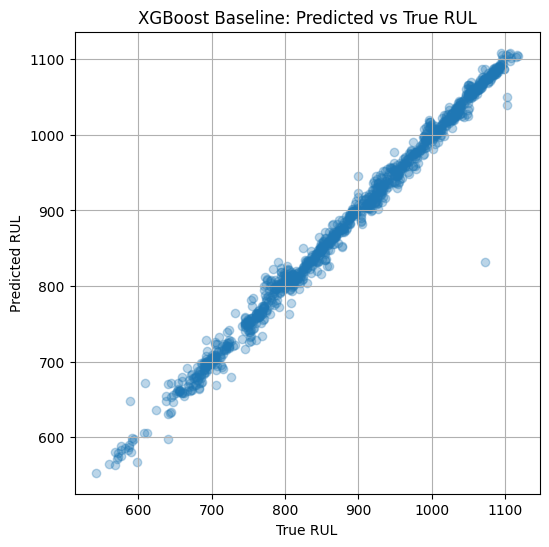

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost Baseline: Predicted vs True RUL")
plt.grid(True)
plt.show()

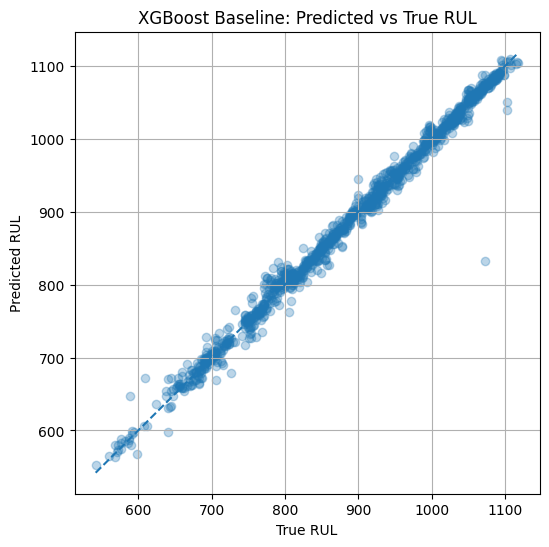

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost Baseline: Predicted vs True RUL")
plt.grid(True)
plt.show()

In [16]:
importances = xgb_model.feature_importances_

feat_imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feat_imp_df

,Feature,Importance
0,Discharge Time (s),0.408727
5,Time constant current (s),0.290786
4,Time at 4.15V (s),0.279202
6,Charging time (s),0.007440
2,Max. Voltage Dischar. (V),0.006351
1,Decrement 3.6-3.4V (s),0.003973
3,Min. Voltage Charg. (V),0.003522


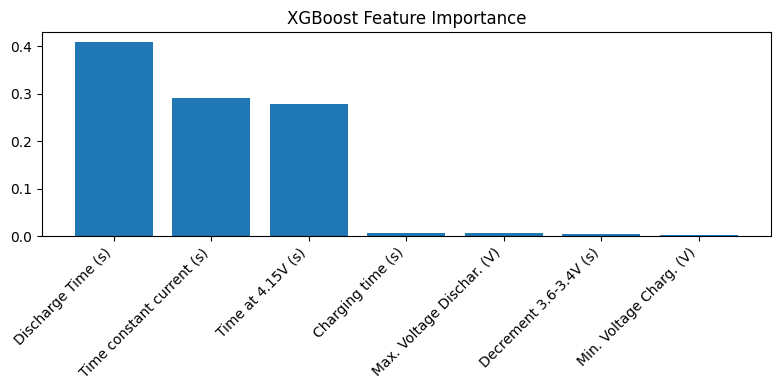

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(feat_imp_df["Feature"], feat_imp_df["Importance"])
plt.xticks(rotation=45, ha="right")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [18]:
results_df = pd.DataFrame({
    "Model": ["XGBoost (with Cycle_Index)"],
    "MAE": [mae],
    "RMSE": [rmse]
})

results_df

,Model,MAE,RMSE
0,XGBoost (with Cycle_Index),7.449925,12.723275
